## 黒潮東側付近におけるカルマンフィルタ


In [1]:
%matplotlib inline
import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from filterpy.gh import GHFilter
from numpy.random import randn
import seaborn as sns
import tqdm
import os
import os.path as osp
import re
import utils
import kf_params

## パラメータの設定

In [2]:
deg_per_mesh = 1/36
ais_lat_max = 1800
ais_lat_min = 750
ais_lon_max = 5401
ais_lon_min = 4211
lat_range = [20-1/36, 50+1/36]
lon_range = [117-1/36, 150+1/36]
map_size_ais = [1050, 1191]
map_size_jcope = [1082, 1191]

### 論文を参考に黒潮付近を設定
黒潮付近<br>
(32, 130), (30, 130), (34, 142), (36,　142)<br>
データ数削減のため，データ範囲をいかに変更<br>
(32, 136), (30, 136), (34, 142), (36,　142)<br>

In [3]:
kurosio_lat_range1 = [30, 32]
kurosio_lat_range2 = [34, 36]
kurosio_lon_range = [136, 142]
line1 = [[kurosio_lat_range1[0], kurosio_lon_range[0]], [kurosio_lat_range2[0], kurosio_lon_range[1]]]
line2 = [[kurosio_lat_range2[0], kurosio_lon_range[1]], [kurosio_lat_range2[1], kurosio_lon_range[1]]]
line3 = [[kurosio_lat_range2[1], kurosio_lon_range[1]], [kurosio_lat_range1[1], kurosio_lon_range[0]]]
line3 = [[kurosio_lat_range1[1], kurosio_lon_range[0]], [kurosio_lat_range1[0], kurosio_lon_range[0]]]

kurosio_row_range1 = [int((kurosio_lat_range1[0]-lat_range[0])/deg_per_mesh), int((kurosio_lat_range1[1]-lat_range[0])/deg_per_mesh)]
kurosio_row_range2 = [int((kurosio_lat_range2[0]-lat_range[0])/deg_per_mesh), int((kurosio_lat_range2[1]-lat_range[0])/deg_per_mesh)]
kurosio_col_range = [int((kurosio_lon_range[0]-lon_range[0])/deg_per_mesh), int((kurosio_lon_range[1]-lon_range[0])/deg_per_mesh)]

## 関数の定義

In [4]:
# data: 1*(n+m)
def dummy_jcope_data(x0, dx, count, noise_factor, size=[10, 10]):
    data = []
    for i in range(count):
        data.append([x0+ dx*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        data[i].append(0)
    return data

# dummpy ais data
# data: 1*(n+m)
def dummy_ais_data(x0, dx, omega, count, noise_factor, size=[10, 10]):
    xy = []
    sum_w = []
    for i in range(count):
        xy.append([x0+ dx*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        sum_w.append([1/(2*noise_factor)  for nm in range(size[0]+size[1])])
        xy[i].append(1)
        sum_w[i].append(0.00001)
    return xy, sum_w

# dummpy ais data
# data: 1*(n+m)
def dummy_ais_data2(x0, dx, omega, count, noise_factor, size=[10, 10]):
    v = []
    theta = []
    sum_w = []
    for i in range(count):
        v.append([x0+ dx*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        theta.append([x0+ omega*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        sum_w.append([1/(2*noise_factor)  for nm in range(size[0]+size[1])])
        v[i].append(1)
        theta[i].append(0)
        sum_w[i].append(0)
    return v, theta, sum_w

# lat lon -> mesh 
def latlon_to_mesh(lat, lon, size=[865, 831]):
    lat_range = lat_range
    lon_range = lon_range
    # lat, lon -> [lon, lat]
    grid0 = int((lon-lon_range[1])/deg_per_mesh)
    grid1 = int((lat-lat_range[0])/deg_per_mesh)
    if grid0<0 or grid0>size[0]: return [-1, -1]
    if grid1<0 or grid1>size[1]: return [-1, -1]
    return [grid0, grid1]

def aisIdx_to_rallon(lat_idx, lon_idx):
    return [lat_idx, lon_idx]*deg_per_mesh

def kurosio(row, col):
    dx = kurosio_col_range[1]-kurosio_col_range[0]
    dy1 = kurosio_row_range2[0] - kurosio_row_range1[0]
    a1 = dy1/dx
    b1 = kurosio_row_range1[0] - a1*kurosio_col_range[0]
    dy2 = kurosio_row_range2[1] - kurosio_row_range1[1]
    a2 = dy2/dx
    b2 = kurosio_row_range1[1] - a1*kurosio_col_range[0]
    
    if(col<kurosio_col_range[0] or col>kurosio_col_range[1]):
        return False
    if(a1*col+b1 > row or a2*col+b2 < row):
        return False
    return True

def kurosio_filter(data, marine_map):
    res = []
    for i in range(map_size_ais[0]):
        for j in range(map_size_ais[1]):
            if kurosio(i, j) and marine_map[i][j]==marine_map[i][j]:
                res.append(data[i][j])
    return np.array(res)

# JCOPE
jcope_data = dummy_jcope_data(0, 0.1, 100, 0.01)

# AIS(観測値) 
ais_data = dummy_ais_data(0, 0.1, 1, 100, 0.001)

# 黒潮マップ
kurosio_map = np.zeros((map_size_ais)) * np.nan
for i in range(map_size_ais[0]):
    for j in range(map_size_ais[1]):
        if kurosio(i, j):
            kurosio_map[map_size_ais[0]-i][j] = 1

kurosio_map_tf = np.zeros((map_size_ais)) == 1 
for i in range(map_size_ais[0]):
    for j in range(map_size_ais[1]):
        if kurosio(i, j):
            kurosio_map_tf[map_size_ais[0]-i][j] = True

def dtIdx(dt1, dt2):
    idx = dt2 - dt1
    idx = int(idx.days*24 + idx.seconds / (60*60))
    return idx

## データの読み込み

In [5]:
year = 2015
month = 9
#day = 19
n_day = 30
epoc_dt = datetime.datetime(year, month, 1, 0, 0, 0)

save_dir = r'E:\shunsukeE\result\kalman09'
path_ais = fr'E:\shunsukeE\data\ais'
path_jcope = fr'E:\shunsukeE\data\eas'

In [6]:
jcope_n = {}
for day in range(1, n_day+1):
    for i in range(24):
        data = pd.read_csv(path_jcope+fr"/{year}{month:02}{day:02}{i:02}/N.csv", encoding="cp932", header=None)
        dt = datetime.datetime(year, month, day, i, 0, 0)
        idx = dtIdx(epoc_dt, dt)
        jcope_n[idx] = data.values
jcope_e = {}
for day in range(1, n_day+1):
    for i in range(24):
        data = pd.read_csv(path_jcope+fr"/{year}{month:02}{day:02}{i:02}/E.csv", encoding="cp932", header=None)
        dt = datetime.datetime(year, month, day, i, 0, 0)
        idx = dtIdx(epoc_dt, dt)
        jcope_e[idx] = data.values

In [7]:
ais_n = {}
ais_e = {}
ais_d = {}

patterns = [fr'(\w+){month:02}....N.csv', fr'(\w+){month:02}....E.csv', fr'(\w+){month:02}....D.csv']


path = path_ais
files = os.listdir(path)
dirs = [f for f in files if os.path.isdir(os.path.join(path, f))]
for d in dirs:
    path2 = osp.join(path, d, 'log')
    files = os.listdir(path2)
    filenames = [f for f in files if os.path.isfile(osp.join(path2, f))]
    for f in filenames:
        if re.match(patterns[0], f):
            f_path = osp.join(path2, f)
            time = f[11:-5]
            day = int(f[13:-7])
            hour = int(f[15:-5])
            dt = datetime.datetime(year, month, day, hour, 0, 0)
            time = dtIdx(epoc_dt, dt)
            if not time in ais_n.keys():
                try:
                    ais_n[time] = []
                    ais_n[time].append(pd.read_csv(f_path, encoding="cp932", header=None))
                    ais_n[time][-1] = ais_n[time][-1].values
                except:
                    print(f'Error in load {f_path}')
            else:
                try:
                    ais_n[time].append(pd.read_csv(f_path, encoding="cp932", header=None))
                    ais_n[time][-1] = ais_n[time][-1].values    
                except:
                    print(f'Error in load {f_path}')
        if re.match(patterns[1], f):
            f_path = osp.join(path2, f)
            time = f[11:-5]
            day = int(f[13:-7])
            hour = int(f[15:-5])
            dt = datetime.datetime(year, month, day, hour, 0, 0)
            time = dtIdx(epoc_dt, dt)
            if not time in ais_e.keys():
                try:
                    ais_e[time] = []
                    ais_e[time].append(pd.read_csv(f_path, encoding="cp932", header=None))
                    ais_e[time][-1] = ais_e[time][-1].values
                except:
                    print(f'Error in load {f_path}')
            else:
                try:
                    ais_e[time].append(pd.read_csv(f_path, encoding="cp932", header=None))
                    ais_e[time][-1] = ais_e[time][-1].values    
                except:
                    print(f'Error in load {f_path}')     
        if re.match(patterns[2], f):
            f_path = osp.join(path2, f)
            time = f[11:-5]
            day = int(f[13:-7])
            hour = int(f[15:-5])
            dt = datetime.datetime(year, month, day, hour, 0, 0)
            time = dtIdx(epoc_dt, dt)
            if not time in ais_n.keys():
                try:
                    ais_d[time] = []
                    ais_d[time].append(pd.read_csv(f_path, encoding="cp932", header=None))
                    ais_d[time][-1] = ais_d[time][-1].values
                except:
                    print(f'Error in load {f_path}')
            else:
                try:
                    ais_d[time].append(pd.read_csv(f_path, encoding="cp932", header=None))
                    ais_d[time][-1] = ais_d[time][-1].values    
                except:
                    print(f'Error in load {f_path}')  

C:\Users\nmri\AppData\Local\Temp\ipykernel_5068\565547633.py:52: DtypeWarning: Columns (935) have mixed types. Specify dtype option on import or set low_memory=False.
  ais_e[time].append(pd.read_csv(f_path, encoding="cp932", header=None))
C:\Users\nmri\AppData\Local\Temp\ipykernel_5068\565547633.py:32: DtypeWarning: Columns (524) have mixed types. Specify dtype option on import or set low_memory=False.
  ais_n[time].append(pd.read_csv(f_path, encoding="cp932", header=None))
C:\Users\nmri\AppData\Local\Temp\ipykernel_5068\565547633.py:46: DtypeWarning: Columns (639,676) have mixed types. Specify dtype option on import or set low_memory=False.
  ais_e[time].append(pd.read_csv(f_path, encoding="cp932", header=None))
C:\Users\nmri\AppData\Local\Temp\ipykernel_5068\565547633.py:26: DtypeWarning: Columns (123,379,398) have mixed types. Specify dtype option on import or set low_memory=False.
  ais_n[time].append(pd.read_csv(f_path, encoding="cp932", header=None))
C:\Users\nmri\AppData\Local\

Error in load E:\shunsukeE\data\ais\150923-12log\log\AisCurr2015092314N.csv


C:\Users\nmri\AppData\Local\Temp\ipykernel_5068\565547633.py:66: DtypeWarning: Columns (65,265,649) have mixed types. Specify dtype option on import or set low_memory=False.
  ais_d[time].append(pd.read_csv(f_path, encoding="cp932", header=None))
C:\Users\nmri\AppData\Local\Temp\ipykernel_5068\565547633.py:46: DtypeWarning: Columns (974) have mixed types. Specify dtype option on import or set low_memory=False.
  ais_e[time].append(pd.read_csv(f_path, encoding="cp932", header=None))


In [8]:
jcope_n.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219,

In [9]:
ais_d.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219,

In [10]:
for i in ais_n.keys():
    for j in range(len(ais_n[i])):
        ais_n[i][j] = ais_n[i][j][0:1050]

for i in ais_e.keys():
    for j in range(len(ais_e[i])):
        ais_e[i][j] = ais_e[i][j][0:1050]


for i in jcope_n.keys():
    jcope_n[i] = jcope_n[i][0:1050]

for i in jcope_e.keys():
    jcope_e[i] = jcope_e[i][0:1050]

nan_map = np.array(jcope_n[i])*0+1

## 黒潮領域の確認

Kurosio:(1050, 1191)


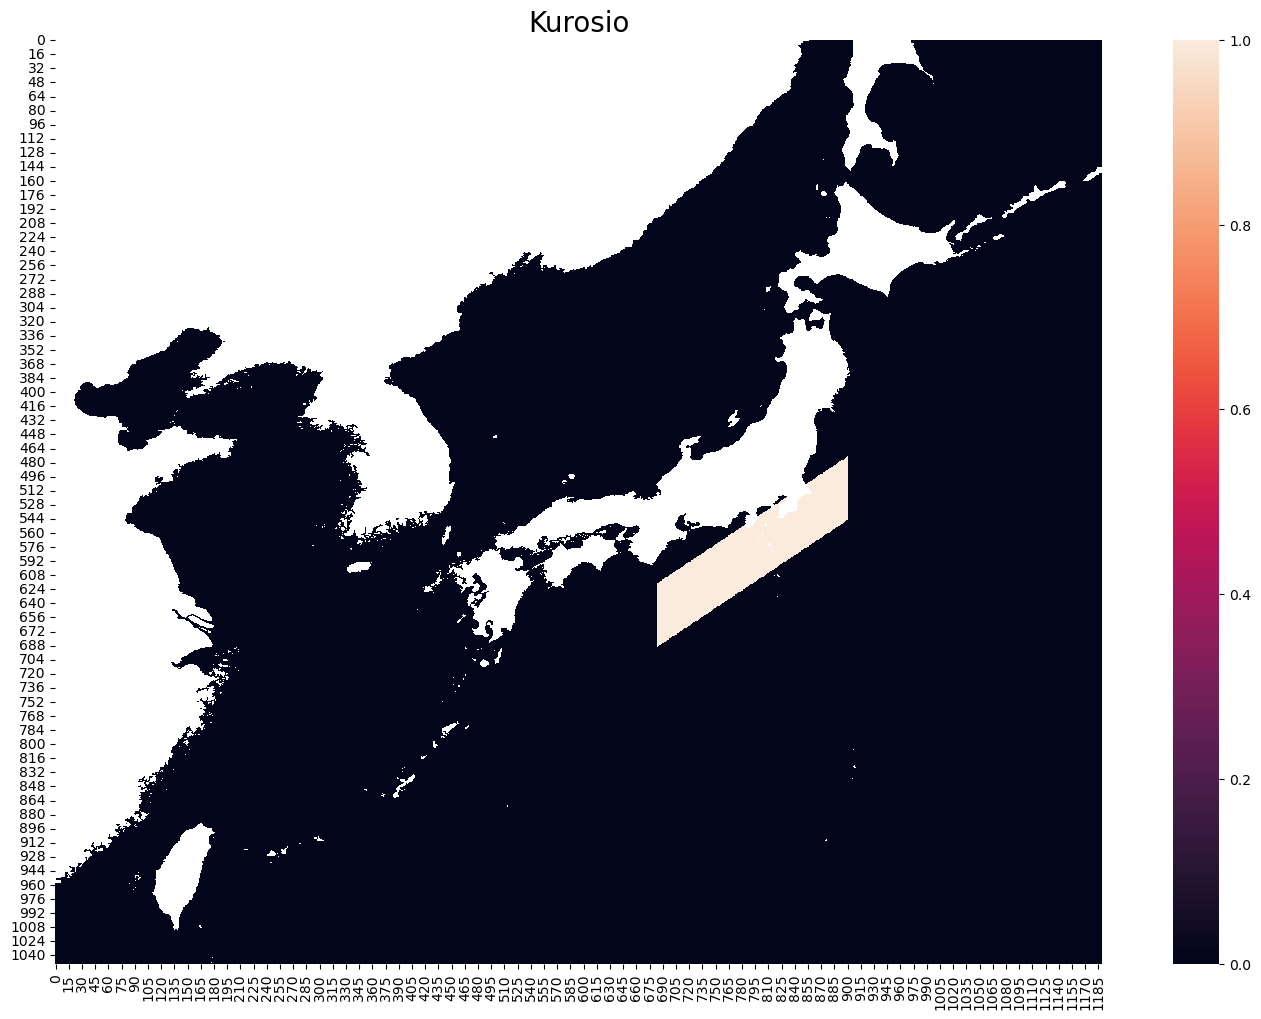

In [11]:
datas = [kurosio_map_tf*nan_map]
data_names = ['Kurosio']
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]}:{data.shape}")
    axes.set_aspect('equal', adjustable='box')
    axes.set_title(data_names[i], fontsize=20)
    axes.set_xlim(0, 1050)
    axes.set_ylim(0, 1090)
    sns.heatmap(data, ax=axes)
plt.show()

全データの可視化

In [12]:
time = f'{month:02}0100'
datas = [ais_n[time][0], ais_e[time][0], jcope_n[time], jcope_e[time]]
data_names = ['AIS N', 'AIS E', 'JCOPE N', 'JCOPE E']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0], [0, 1], [1, 0], [1, 1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]}:{data.shape}")
    a, b = plot_place[i]
    axes[a, b].set_title(data_names[i], fontsize=20)
    axes[a, b].set_xlim(0, 1082)
    axes[a, b].set_ylim(0, 1090)
    sns.heatmap(data, ax=axes[a, b])
plt.show()

KeyError: '090100'














黒潮のみ可視化

AIS N:(1050, 1191)
AIS E:(1050, 1191)
JCOPE N:(1050, 1191)
JCOPE E:(1050, 1191)


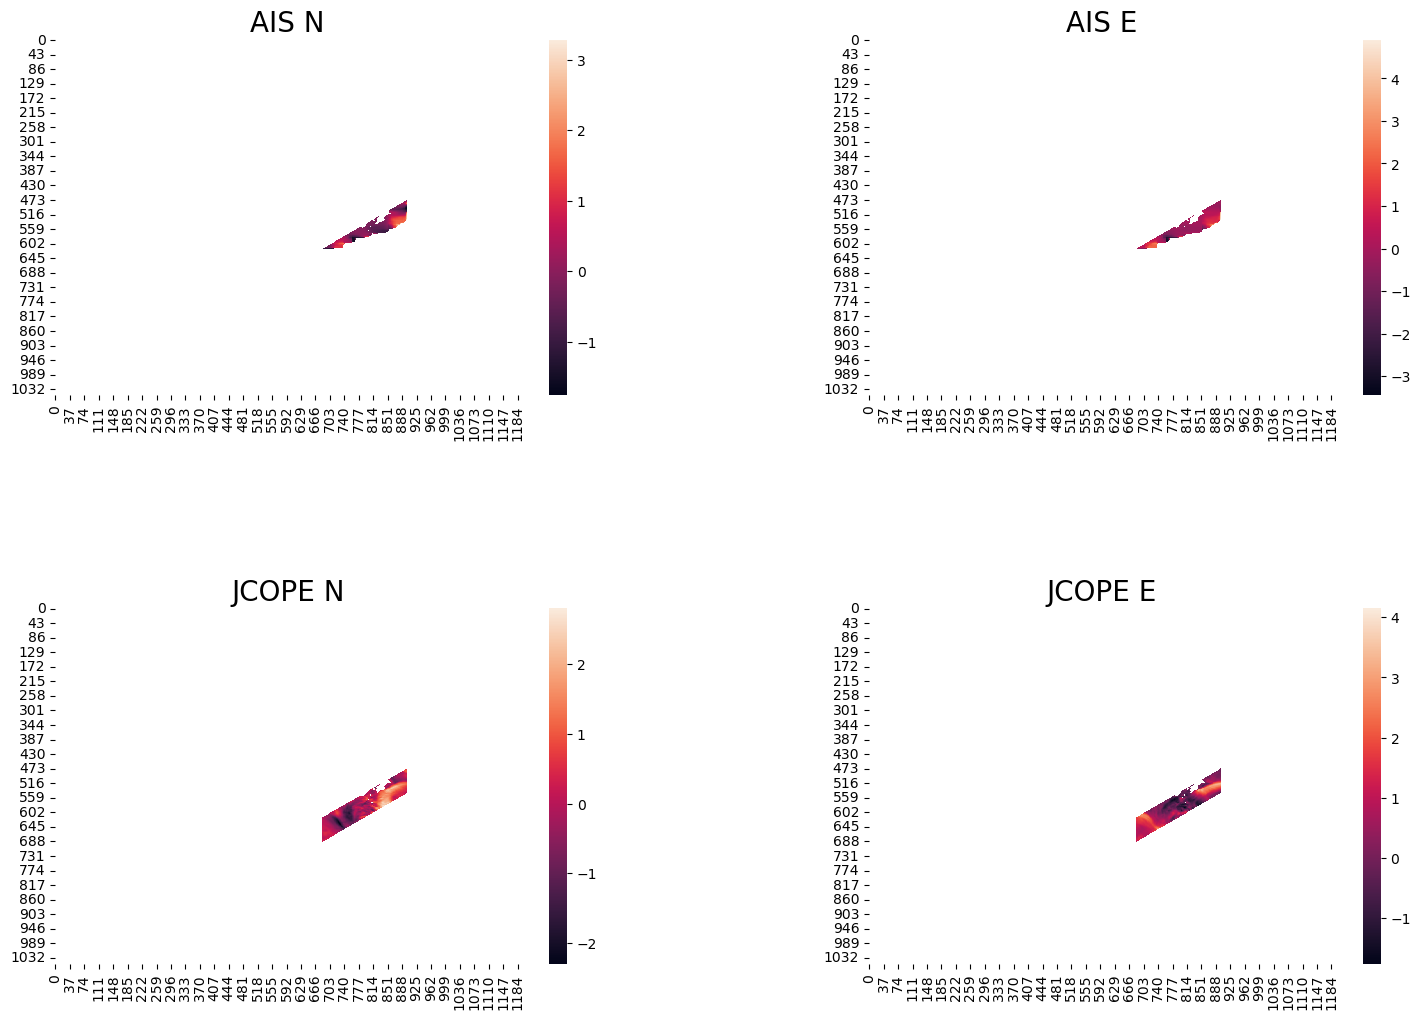

In [31]:
time = f'{month:02}0100'
datas = [ais_n[time][0]*kurosio_map, 
         ais_e[time][0]*kurosio_map, 
         jcope_n[time]*kurosio_map, 
         jcope_e[time]*kurosio_map]
data_names = ['AIS N', 'AIS E', 'JCOPE N', 'JCOPE E']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0], [0, 1], [1, 0], [1, 1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]}:{data.shape}")
    a, b = plot_place[i]
    axes[a, b].set_title(data_names[i], fontsize=20)
    axes[a, b].set_xlim(0, 1082)
    axes[a, b].set_ylim(0, 1090)
    sns.heatmap(data, ax=axes[a, b])
plt.show()

黒潮領域東側のデータ数(陸地を除く)は9808<br>
存在しないデータが半数以上あるので，もっと計算量を小さくはできる<br>
ちなみに，陸地込みの黒潮全域は31321<br>

In [32]:
# 黒潮領域のデータ数の確認
time = f'{month:02}0100'
datas = [kurosio_filter(ais_n[time][0], nan_map), 
         kurosio_filter(ais_e[time][0], nan_map), 
         kurosio_filter(jcope_n[time], nan_map),
         kurosio_filter(jcope_e[time], nan_map)]
data_name = ['AIS N', 'AIS E', 'JCOPE N', 'JCOPE E']
for i, d in enumerate(datas):
    print(f"データ名: {data_name[i]}, データ数:{len(d)}, 存在しないデータ数: {np.sum(d!=d)}")

データ名: AIS N, データ数:9845, 存在しないデータ数: 4108
データ名: AIS E, データ数:9845, 存在しないデータ数: 4108
データ名: JCOPE N, データ数:9845, 存在しないデータ数: 0
データ名: JCOPE E, データ数:9845, 存在しないデータ数: 0


## カルマンフィルタの設計
### 状態空間モデル
$\hat{x(t)}^{-} = A\hat{x}(t-1)$<br>
$\hat{x(t)}^{-} = J(K) + a(\hat{x}(t-1)-J(k-1))$<br>
$J(k) = \left[ x(0, 0), x(0, 1), \cdots, x(lon-1, lat-1), \cdots, y(0, 0), y(0, 1), \cdots, y(lon-1, lat-1), 1 \right]$<br>
$
A = 
\begin{pmatrix}
   a & 0 & \cdots & 0 & (J(k)-aJ(k-1))(0, 0) \\
   0 & a & \cdots & 0 & (J(k)-aJ(k-1))(0, 1) \\
   \vdots & \cdots &　 &　 & \vdots  \\
   0 & \cdots & 0 & a & (J(k)-aJ(k-1))(lon-1, lat-1)\\
   0 & \cdots & 0 & 1 & 1
\end{pmatrix}
$
<br>
### 観測値
$y(t) = C\hat{x}(t)$<br>
$y(t) = \left[ x(0, 0), x(0, 1), \cdots, x(lon-1, lat-1), \cdots, y(0, 0), y(0, 1), \cdots, y(lon-1, lat-1), 1 \right]$<br>
$
C = 
\begin{pmatrix}
   1 & 0 & \cdots & 0 & 0 \\
   0 & 1 & \cdots & 0 & 0 \\
   \vdots & \cdots &　 &　 & \vdots  \\
   0 & \cdots & 0 & 1 & 0\\
\end{pmatrix}
$

## 黒潮領域のカルマンフィルター
aisの信頼度のデータを計算するの忘れたので，とりあえず誤差の値は0.01にする<br>
filterpyのライブラリの説明：https://filterpy.readthedocs.io/en/latest/kalman/KalmanFilter.html

In [15]:
import pickle
from filterpy.common import Saver
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

time0 = f'{month:02}0100'
data = kurosio_filter(ais_n[time0][0], nan_map)
n = len(data)
m = 1

def F_element(i, j, k, data):
    a = 0.5
    if i==j:
        return a
    elif i==n+m:
        jcope0 = data[k-1]
        jcope1 = data[k]
        residual = jcope1[i] - jcope0[i]
        return residual
    else:
        return 0

# TODO
def H_element(i, j):
    if i==j:
        return 1
    else:
        return 0
    
def R_mat(sigma):
    R = np.zeros((n*m+1, n*m+1))
    for i in range(len(sigma)):
        R[i][i] = sigma[i]
    return R


kf = KalmanFilter(dim_x=n*m+1, dim_z=n*m+1)
ais_n0 = kurosio_filter(ais_n[0][0], nan_map) # 時刻0のais data
ais_n0 = np.concatenate([ais_n0, [1]])
ais_n0 = ais_n0.reshape(len(ais_n0), 1)
ais_n0[ais_n0!=ais_n0] = 0

jcope_n0 = kurosio_filter(jcope_n[0], nan_map) # 時刻0のjcope data
jcope_n0 = np.concatenate([jcope_n0, [1]])
jcope_n0 = jcope_n0.reshape(len(jcope_n0), 1)
jcope_n0[jcope_n0!=jcope_n0] = 0

# F関数, H関数
kf.F = np.array([[F_element(i, j, 1, jcope_n0)  for i in range(n*m+1)] for j in range(n*m+1)])
kf.H = np.array([[H_element(i, j)  for i in range(n*m+1)] for j in range(n*m+1)])


# 分散共分散行列
kf.Q = np.eye(n*m+1)*0.001 # システム誤差(ais)
#kf.R = R_mat(ais_sigmas2[0]) # 観測誤差(jcope)
kf.R = np.eye(n*m+1)*0.001

kf.x = jcope_n0 # 初期位置
kf.P = np.eye(n*m+1) # 初期事後誤差共分散行列
#s = Saver(kf) # save用

# 10時刻分（13時刻でメモリエラー出るので）
print('Start KalmanFilter')
for t in tqdm.tqdm(range(1,16)):
    # 予測ステップ
    kf.predict()
    
    # フィルタリングステップ
    # kf.R = R_mat(ais_sigmas2[t])
    kf.R = np.eye(n*m+1)*0.001
    y = kurosio_filter(ais_n[t][0], nan_map)
    y = np.concatenate([y, [1]])
    y = y.reshape(len(y), 1)
    y[y!=y] = 0
    # nanの処理と誤差の最大化
    kf.update(y)
    
    """
    target = 88
    if y[target]!=0.0:
        print(f"t:{t}")
        print(f"R:{kf.R[target][target]}")
        print(f"x:{kf.x[target]}")
        print(f"y:{y[target]}") 
    """
    
    #s.save()  # 現在状態を記録する
    #print(f'Saved {t} time results')
    
    with open(f'{save_dir}/saverX{t}.pkl', 'wb') as f:
        pickle.dump(kf.x, f)
    with open(f'{save_dir}/saverZ{t}.pkl', 'wb') as f:
        pickle.dump(kf.z, f)
        
    # 関数の更新
    x = kurosio_filter(jcope_n[t], nan_map)
    x = np.concatenate([x, [1]])
    x = x.reshape(len(x), 1)
    x[x!=x] = 0
    kf.F = np.array([[F_element(i, j, t, x)  for i in range(n*m+1)] for j in range(n*m+1)])
    kf.H = np.array([[H_element(i, j)  for i in range(n*m+1)] for j in range(n*m+1)])

print('Finished KalmanFilter')

Start KalmanFilter


100%|█████████████████████████████████████████████████████████████████████████████████| 15/15 [31:52<00:00, 127.51s/it]

Finished KalmanFilter


先頭の2,000くらいのデータは無い<br>

In [ ]:
print(len(s.x[0]))
#print(f"s.x {s.x}")
#print(f"s.z {s.z}")
plt.title("Cur of last Time")
plt.xlabel("Index")
plt.ylabel(f"(cur N) value")
plt.plot(np.arange(len(np.array(s.x)[-1])), np.array(s.x)[-1], label=f'filtered data')
plt.scatter(np.arange(len(np.array(s.x)[-1])), np.array(s.z)[-1], label=f'obs', c='r')
plt.legend()
plt.show()
np.sum(np.array(s.x) == np.array(s.x))

inexが8,000の場所のフィルター過程を見てみる<br>
大体aisとjcopeの値を終えていてよさそう

In [ ]:
print(len(s.x[0]))
#print(f"s.x {s.x}")
#print(f"s.z {s.z}")
i = 8000
dataX = np.array(s.x).T
dataX = dataX[0][i]
dataZ = np.array(s.z).T
dataZ = dataZ[0][i]
dataY = np.array(s.y).T
dataY = dataY[0][i]

plt.title(f"Filltered kalman (index={i})")
plt.xlabel("Time")
plt.ylabel(f"Cur N")
plt.plot(np.arange(len(dataX)), dataX, label=f'filtered data')
plt.scatter(np.arange(len(dataX)), dataZ, label=f'jcope', c='r')
plt.scatter(np.arange(len(dataX)), dataY, label=f'ais', c='b')
plt.legend()
plt.show()
np.sum(np.array(s.x) == np.array(s.x))

9846


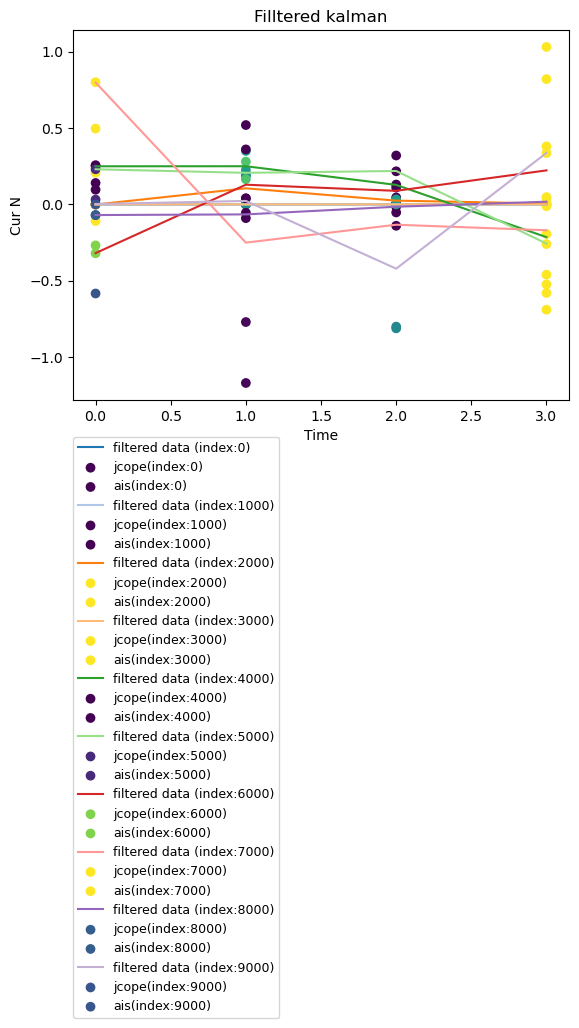

39384

In [49]:
import matplotlib.cm as cm 

print(len(s.x[0]))
#print(f"s.x {s.x}")
#print(f"s.z {s.z}")
data = np.array(s.x).T[0]
plt.title(f"Filltered kalman")
plt.xlabel("Time")
plt.ylabel(f"Cur N")
target_index = np.arange(10)*1000
for n, i in enumerate(target_index):
    dataX = np.array(s.x).T
    dataX = dataX[0][i]
    dataZ = np.array(s.z).T
    dataZ = dataZ[0][i]
    dataY = np.array(s.y).T
    dataY = dataY[0][i]

    plt.plot(np.arange(len(dataX)), dataX, label=f'filtered data (index:{i})', c=cm.tab20(n))
    plt.scatter(np.arange(len(dataX)), dataZ, label=f'jcope(index:{i})', c=cm.tab20(n))
    plt.scatter(np.arange(len(dataX)), dataY, label=f'ais(index:{i})', c=cm.tab20(n))
    
plt.legend(bbox_to_anchor=(0, -0.1), loc='upper left', borderaxespad=0, fontsize=9)
plt.show()
np.sum(np.array(s.x) == np.array(s.x))

## 進捗報告用

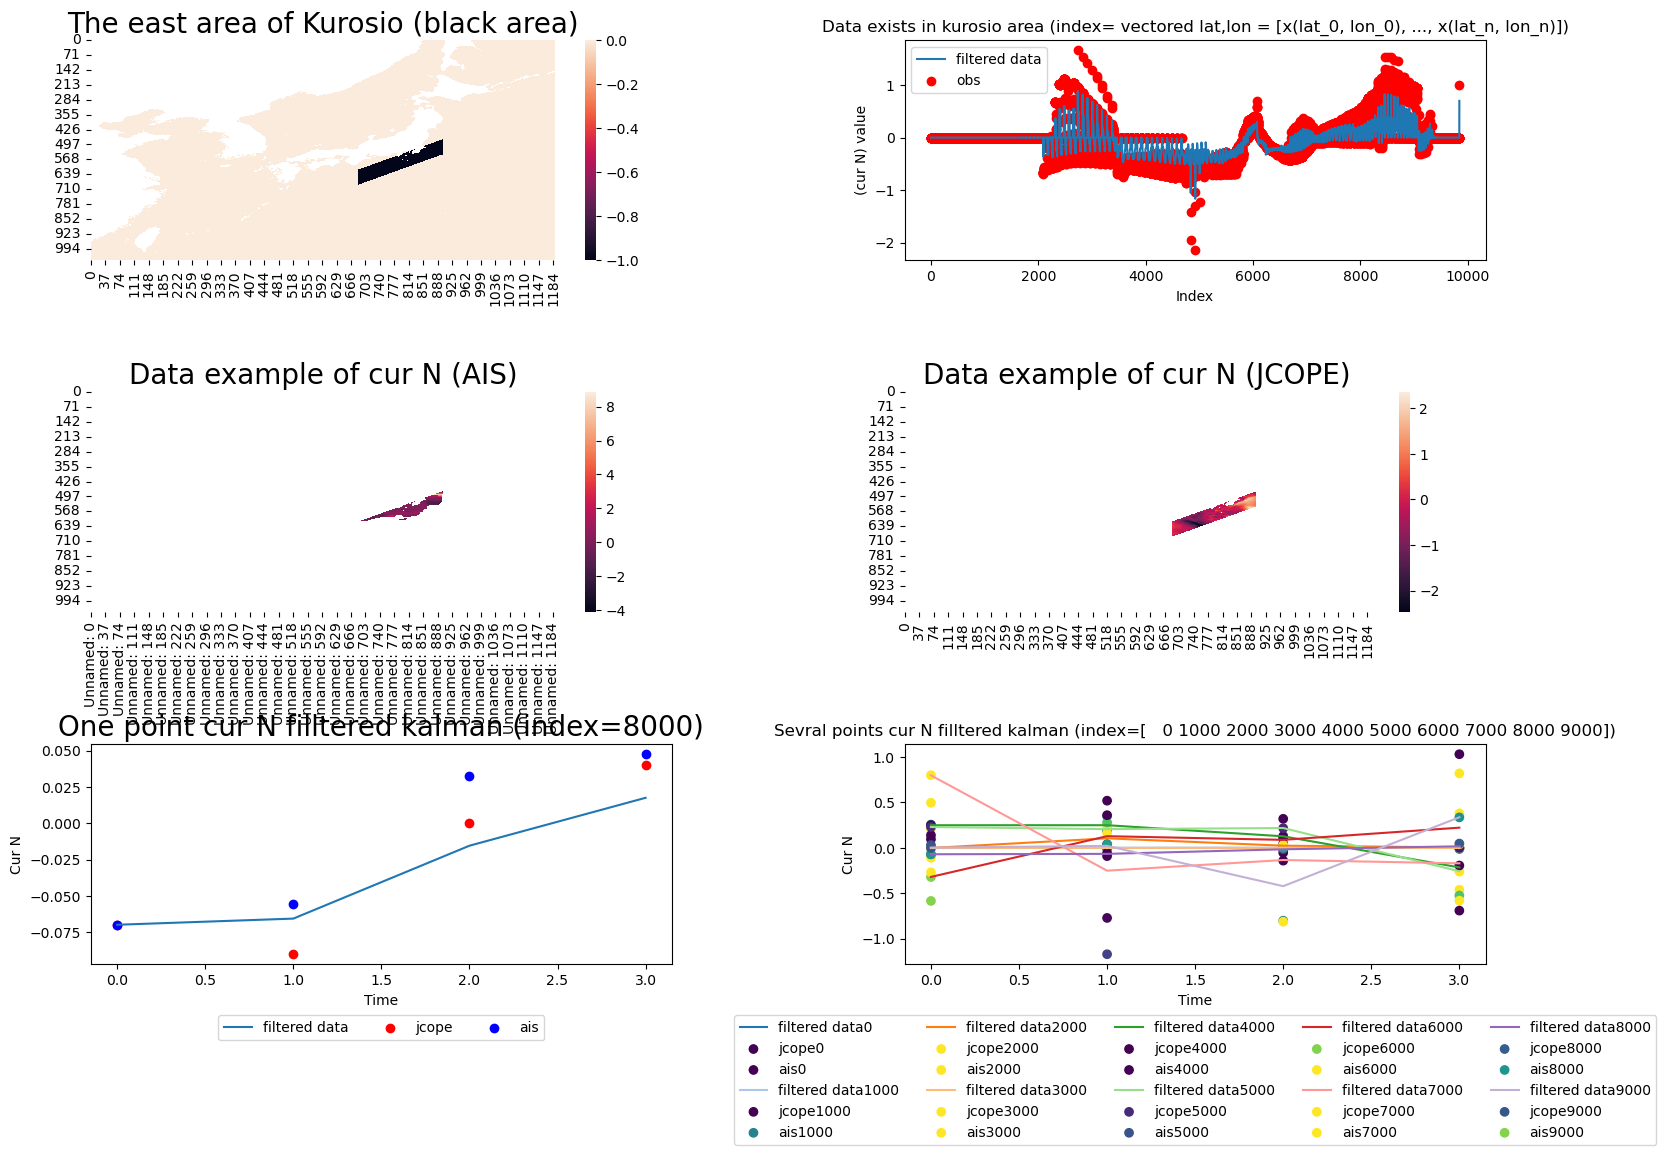

In [51]:
data = kurosio_map_tf*-1*nan_map
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
a, b = [0, 0]
axes[a, b].set_title("The east area of Kurosio (black area)", fontsize=20)
sns.heatmap(data, ax=axes[a, b])
    
data = ais_n_mapped[0]*kurosio_map
a, b = [1, 0]
axes[a, b].set_title("Data example of cur N (AIS)", fontsize=20)
axes[a, b].set_xlim(0, 1082)
axes[a, b].set_ylim(0, 1090)
sns.heatmap(data, ax=axes[a, b])


a, b = [0, 1]
axes[a, b].set_title("Data exists in kurosio area (index= vectored lat,lon = [x(lat_0, lon_0), ..., x(lat_n, lon_n)])")
axes[a, b].set_xlabel("Index")
axes[a, b].set_ylabel(f"(cur N) value")
axes[a, b].plot(np.arange(len(np.array(s.x)[-1])), np.array(s.x)[-1], label=f'filtered data')
axes[a, b].scatter(np.arange(len(np.array(s.x)[-1])), np.array(s.z)[-1], label=f'obs', c='r')
axes[a, b].legend()


data = jcope_n[0]*kurosio_map
a, b = [1, 1]
axes[a, b].set_title("Data example of cur N (JCOPE)", fontsize=20)
axes[a, b].set_xlim(0, 1082)
axes[a, b].set_ylim(0, 1090)
sns.heatmap(data, ax=axes[a, b])

i = 8000
dataX = np.array(s.x).T
dataX = dataX[0][i]
dataZ = np.array(s.z).T
dataZ = dataZ[0][i]
dataY = np.array(s.y).T
dataY = dataY[0][i]
a, b = [2, 0]
axes[a, b].set_title(f"One point cur N filltered kalman (index={i})", fontsize=20)
axes[a, b].set_xlabel("Time")
axes[a, b].set_ylabel(f"Cur N")
axes[a, b].plot(np.arange(len(dataX)), dataX, label=f'filtered data')
axes[a, b].scatter(np.arange(len(dataX)), dataZ, label=f'jcope', c='r')
axes[a, b].scatter(np.arange(len(dataX)), dataY, label=f'ais', c='b')
axes[a, b].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3)

data = np.array(s.x).T[0]
plt.title(f"Filltered kalman")
plt.xlabel("Time")
plt.ylabel(f"Cur N")
a, b = [2, 1]
target_index = np.arange(10)*1000
axes[a, b].set_title(f"Sevral points cur N filltered kalman (index={target_index})", fontsize=12)
axes[a, b].set_xlabel("Time")
axes[a, b].set_ylabel(f"Cur N")
for n, i in enumerate(target_index):
    dataX = np.array(s.x).T
    dataX = dataX[0][i]
    dataZ = np.array(s.z).T
    dataZ = dataZ[0][i]
    dataY = np.array(s.y).T
    dataY = dataY[0][i]
    
    axes[a, b].plot(np.arange(len(dataX)), dataX, label=f'filtered data{i}', c=cm.tab20(n))
    axes[a, b].scatter(np.arange(len(dataX)), dataZ, label=f'jcope{i}',  c=cm.tab20(n))
    axes[a, b].scatter(np.arange(len(dataX)), dataY, label=f'ais{i}',  c=(cm.tab20(n)[0], cm.tab20(n)[1], cm.tab20(n)[2], 0.5))
    axes[a, b].legend()
    axes[a, b].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=5)

plt.show()